In [2]:
import pandas as pd

df = pd.read_csv("data/pokemon_card_price_dataset.csv")

df["set_release_date"] = pd.to_datetime(
    df["set_release_date"].astype(str).str[:10]
)

df = df[~df["primary_type"].str.lower().str.contains("trainer", na=False)]

excluded = [
    "item",
    "energy",
    "special energy",
    "pokemon tool",
    "stadium",
    "supporter",
    "tool"
]

df = df[~df["primary_type"].str.lower().isin(excluded)]

df["retreat_cost_count"] = df["retreat_cost_count"].fillna(0)
df["has_free_retreat"]=(df["retreat_cost_count"]==0).astype(int) # add a column to see if the card has a retreat cost of 0 (which should increase value of card)

df = df.drop(columns=["product_url"])

print(df.head())



   card_id  card_name  set_id  set_name set_release_date  market_price_usd  \
0    42386       Abra     604  Base Set       1999-01-09              1.06   
1    42346   Alakazam     604  Base Set       1999-01-09             68.55   
2    42364   Arcanine     604  Base Set       1999-01-09              3.84   
3    42357   Beedrill     604  Base Set       1999-01-09              7.37   
4    42360  Blastoise     604  Base Set       1999-01-09            213.81   

  finish_type     rarity     hp primary_type  ... retreat_cost_count  \
0      Normal     Common   30.0      Psychic  ...                0.0   
1    Holofoil  Holo Rare   80.0      Psychic  ...                3.0   
2      Normal   Uncommon  100.0         Fire  ...                3.0   
3      Normal       Rare   80.0        Grass  ...                0.0   
4    Holofoil  Holo Rare  100.0        Water  ...                3.0   

   weakness_count  resistance_count  attack_count  avg_attack_cost_length  \
0             1.0    

# Machine Learning:

In [7]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

df = df.dropna(subset=['market_price_usd'])
df['log_price'] = np.log1p(df['market_price_usd'])

# Train on older cards, test on newer cards
threshold_age = df['age_days'].quantile(0.10)
train_df = df[df['age_days'] > threshold_age]
test_df = df[df['age_days'] <= threshold_age]

feature_cols = [
    'finish_type', 'rarity', 'hp', 'primary_type', 'primary_subtype', 
    'retreat_cost_count', 'has_free_retreat', 'weakness_count', 
    'resistance_count', 'attack_count', 'set_total', 'age_days'
]

X_train = train_df[feature_cols]
y_train = train_df['log_price']

X_test = test_df[feature_cols]
y_test = test_df['log_price']

categorical_features = ['finish_type', 'rarity', 'primary_type', 'primary_subtype']
numeric_features = [
    'hp', 'retreat_cost_count', 'has_free_retreat', 'weakness_count', 
    'resistance_count', 'attack_count', 'set_total', 'age_days'
]

# Fills NAs with 0s then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Build Models: 3
linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

print("Training Linear (Ridge) Model...")
linear_pipeline.fit(X_train, y_train)

print("Training Random Forest Model...")
rf_pipeline.fit(X_train, y_train)


def evaluate_model(name, pipeline, X_test, y_test_log, y_test_actual):
    # Predict log prices
    y_pred_log = pipeline.predict(X_test)
    
    # Reverse the log transform to calculate understandable errors in actual dollars
    y_pred_actual = np.expm1(y_pred_log) 
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual) # Note: R2 on actuals can be sensitive to extreme outliers
    
    print(f"--- {name} Performance ---")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R^2:  {r2:.4f}\n")

y_test_actual = np.expm1(y_test)

evaluate_model("Linear Regression (Ridge)", linear_pipeline, X_test, y_test, y_test_actual)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test, y_test_actual)

Training Linear (Ridge) Model...
Training Random Forest Model...
--- Linear Regression (Ridge) Performance ---
MAE:  $11.82
RMSE: $51.87
R^2:  0.0301

--- Random Forest Performance ---
MAE:  $11.75
RMSE: $51.24
R^2:  0.0534



# Analysis:

The mean absolute error (MAE) is \~$11.80 which means on average, our model is off by around $11.80. That can be considered good if the price of the card is high, but if the price is low at a few dollars, that means our prediction is way off.

The root mean square error (RMSE) is \~$51.50. RMSE penalizes large errors heavily, so the huge gap between MAE ($11) and RMSE ($51) means our model is making big mistakes. It could mean that it is failing to predict outliers such as super rare cards or expensive chase cards.

The low R^2 of 0.03 to 0.05 means there is a 3% to 5% variance in the Pokemon card prices.
This means that the physical attributes such as HP, retreat cost, and weakness are poor predictors of the market value.

A reason why our model is so far off might be because we assumed card prices are based on gameplay utility like the card's HP, attack cost, or type. The real guiding factor behind the card prices may be other reasons, such as popularity among the Pokemon/card collector community, nostalgia from long time Pokemon fans, card artwork/design, or rarity of the card.

# Visualization:

C:\Users\Hunter\AppData\Local\Temp\ipykernel_55440\3578269552.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


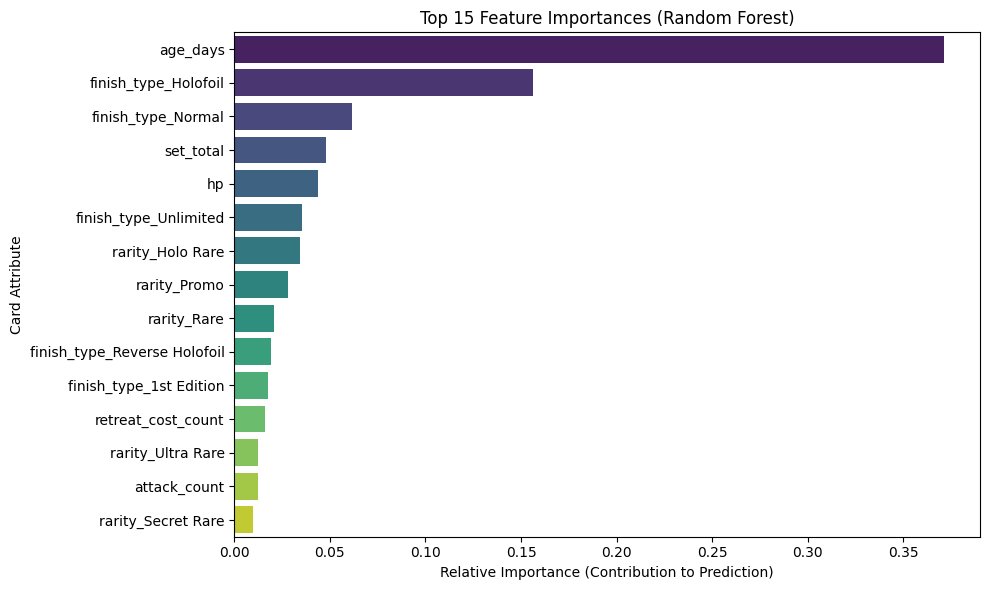

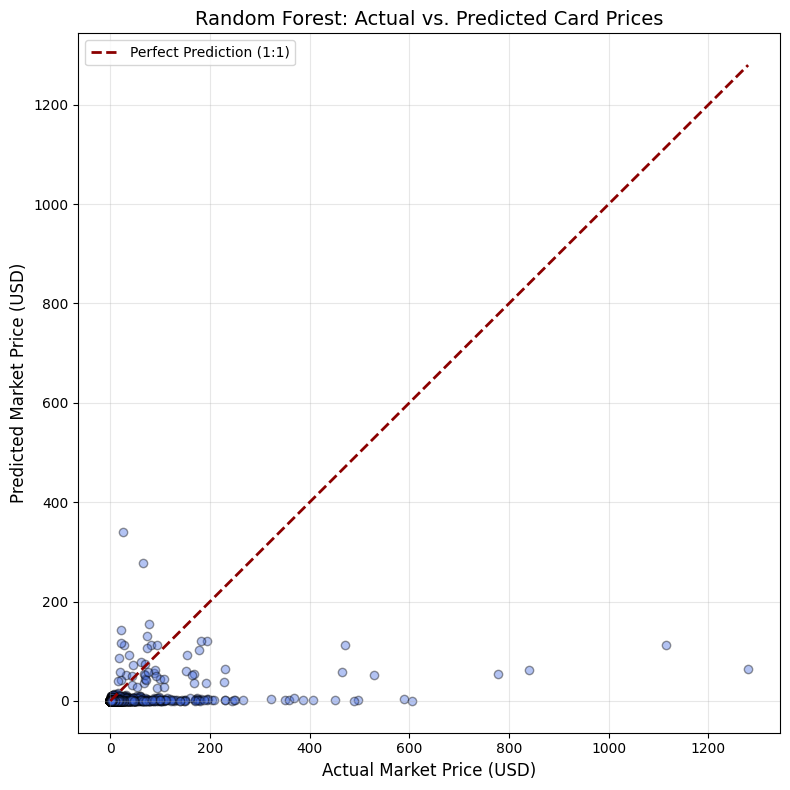

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# Plot the Top 15 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.ylabel('Card Attribute')
plt.tight_layout()
plt.show()

y_pred_log_rf = rf_pipeline.predict(X_test)

y_pred_actual_rf = np.expm1(y_pred_log_rf)

plt.figure(figsize=(8, 8))
# Plot actual prices vs predicted prices
plt.scatter(y_test_actual, y_pred_actual_rf, alpha=0.4, color='royalblue', edgecolor='k')

max_val = max(y_test_actual.max(), y_pred_actual_rf.max())
plt.plot([0, max_val], [0, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Prediction (1:1)')

plt.title('Random Forest: Actual vs. Predicted Card Prices', fontsize=14)
plt.xlabel('Actual Market Price (USD)', fontsize=12)
plt.ylabel('Predicted Market Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Chart Anaylsis:
The first chart (Top 15 Feature Importances) ranks which variables the random forest relied on the most to make its price guesses. Based on our chart, the top 3 most important feature types are age_days which is how old the card is, finish_type_Holofoil, and finish_type_Normal, which are part of the card design. This confirms what we assumed earlier, the main driving point of card prices are rarity (card age) and card design, rather than the card's gameplay utility.

The second chart (Actual vs Predicted Card Prices) graphs the difference between the price predicted vs the actual price, and the red dotted line represents where the dots should be if the model was 100% accurate. In our chart we see majority of the dots clustered around the bottom left, which the model predicts decently well. As we move to the right towards the more expensive cards, the dots are low and below the red line which means the model is predicting low prices for expensive cards. This represents our huge RMSE gap from earlier.